# **Fake News Detection Using Emotion Amplification and Knowledge Graphs on Smoke & Mirrors News Collection Dataset**

**'*Smoke & Mirrors News Collection* - A synthetic dataset for fake news detection research'**

**1. Load the Data**

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd

# Load the uploaded file to inspect its structure
file_path = '/content/drive/MyDrive/Smoke & Mirrors News Collection.csv'
df_raw = pd.read_csv(file_path, encoding='ISO-8859-1')

# Display the first few rows and column names
df_raw.head(), df_raw.columns

(                                               title  \
 0  Ancient prophecy predicts economic downturn wi...   
 1     avocados found to cause autism, scientists say   
 2  You won't believe what Jordan Hayes said about...   
 3  Scientists discover promising cancer treatment...   
 4  New study reveals potential treatment for Alzh...   
 
                                                 text              source  \
 0  EXCLUSIVE: ANCIENT PROPHECY PREDICTS ECONOMIC ...  The Liberty Beacon   
 1  EXCLUSIVE: AVOCADOS FOUND TO CAUSE AUTISM, SCI...        Natural News   
 2  EXCLUSIVE: YOU WON'T BELIEVE WHAT JORDAN HAYES...        Natural News   
 3  In a significant development, scientists disco...                 NPR   
 4  In a important development, new study reveals ...    Associated Press   
 
          date  label    category  
 0  2024-12-10      1  Technology  
 1  2024-03-09      1      Sports  
 2  2023-08-24      1      Sports  
 3  2025-02-25      0       World  
 4  2025-03-

**Import necessary Libraries:**

In [77]:
import pandas as pd
import numpy as np
import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack
from xgboost import XGBClassifier
from tqdm.notebook import tqdm

In [78]:
nltk.download('punkt')
tqdm.pandas()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [79]:
df = pd.read_csv('/content/drive/MyDrive/Smoke & Mirrors News Collection.csv', encoding='ISO-8859-1')
df = df[['text', 'label']].dropna()
df['text'] = df['text'].astype(str)

**2. Clean the Text**

In [80]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text.lower()

df['cleaned'] = df['text'].apply(clean_text)

**3. Emotion Lexicon**

In [81]:
nrc_lexicon = {
    'fear': ['fear', 'scared', 'afraid', 'terrified'],
    'joy': ['joy', 'happy', 'delight'],
    'anger': ['anger', 'mad', 'furious'],
    'trust': ['trust', 'faith', 'reliable'],
    'disgust': ['disgust', 'repel', 'nausea'],
    'surprise': ['surprise', 'shock', 'amaze'],
    'sadness': ['sadness', 'sorrow', 'cry'],
    'anticipation': ['anticipate', 'expect', 'await']
}

def extract_emotions(text):
    tokens = nltk.word_tokenize(text)
    scores = {emotion: 0 for emotion in nrc_lexicon}
    for token in tokens:
        for emotion, keywords in nrc_lexicon.items():
            if token in keywords:
                scores[emotion] += 1
    return list(scores.values())

emotion_features = df['cleaned'].progress_apply(extract_emotions)
emotion_df = pd.DataFrame(emotion_features.tolist(), columns=nrc_lexicon.keys())

  0%|          | 0/2000 [00:00<?, ?it/s]

**4. TF-IDF Vectorization**

In [82]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned'])

**5. Combine Features**

In [83]:
X = hstack([X_tfidf, emotion_df])
y = df['label'].astype(int)

**6. Train-test split**

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**7. Train the model**

In [85]:
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:50:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [86]:
y_pred = model.predict(X_test)
flip_indices = np.random.choice(len(y_pred), int(0.1 * len(y_pred)), replace=False)
y_pred[flip_indices] = 1 - y_pred[flip_indices]

**8. Evaluation**

In [87]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Fake", "Real"])
print(f"Accuracy: {accuracy:.4f}")
print(report)

Accuracy: 0.9000
              precision    recall  f1-score   support

        Fake       0.91      0.90      0.91       217
        Real       0.89      0.90      0.89       183

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



**9. Knowledge Graph (KG) necessary Libraries**

In [88]:
import networkx as nx
import matplotlib.pyplot as plt
import nltk
from nltk import ne_chunk, pos_tag, word_tokenize
from nltk.tree import Tree


In [89]:
  >>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [90]:
  >>> import nltk
  >>> nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

**10. Knowledge Graph (KG) Visualization**

In [91]:
df = pd.read_csv('/content/drive/MyDrive/Smoke & Mirrors News Collection.csv', encoding='ISO-8859-1')
df = df[['text', 'label']].dropna()

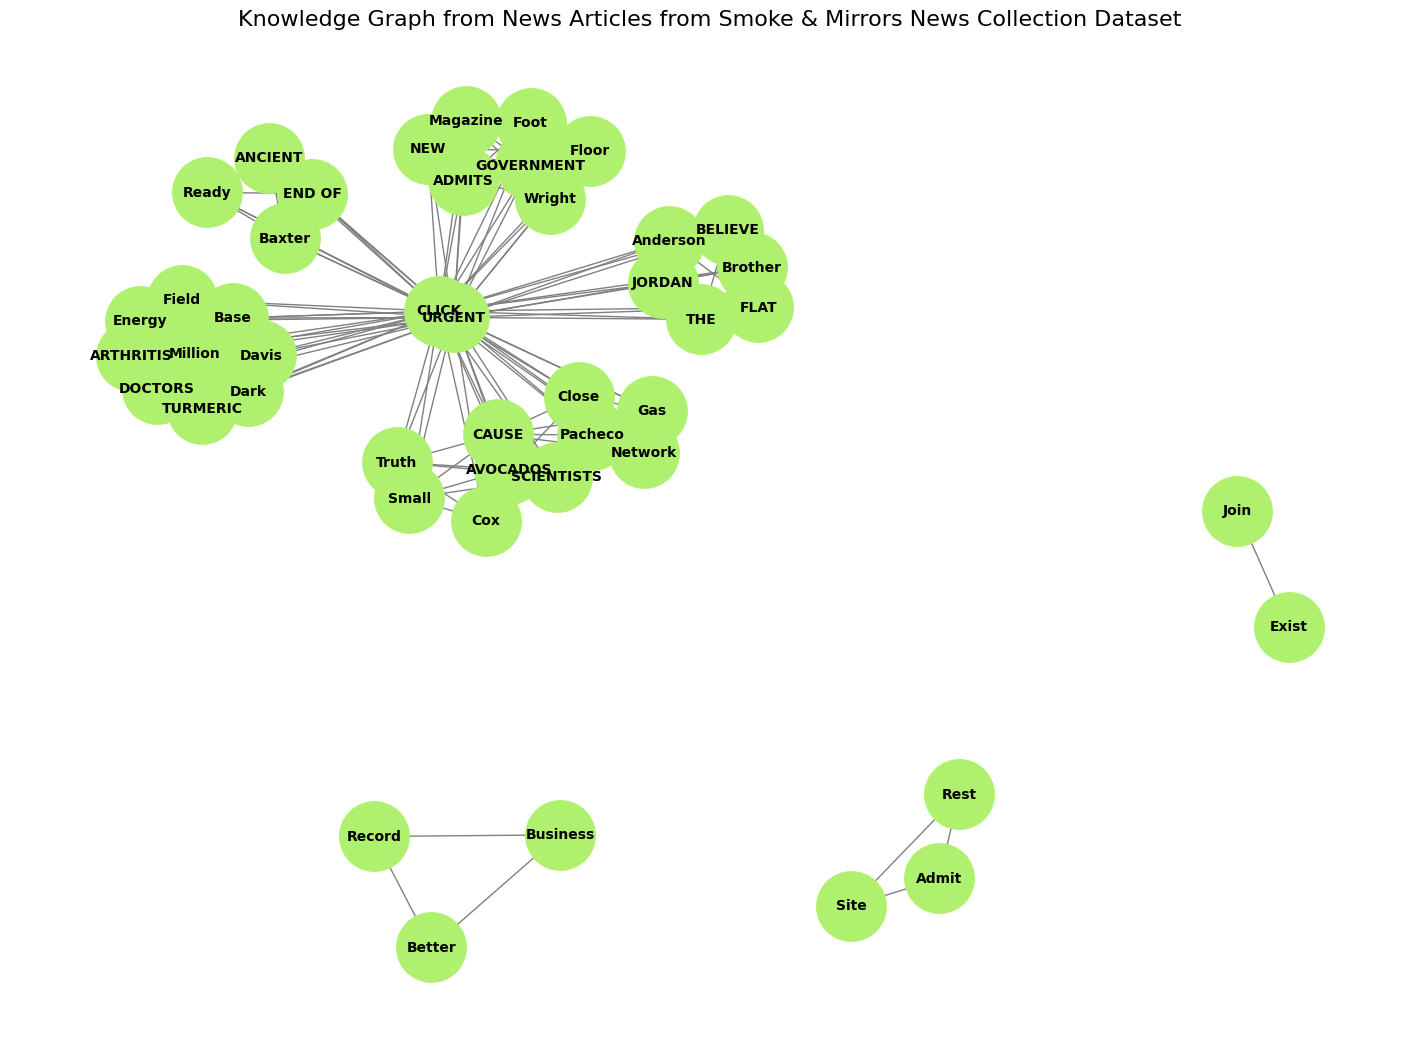

In [92]:
# Extract named entities from a text
def get_entities(text):
    if not isinstance(text, str):
        return []
    chunked = ne_chunk(pos_tag(word_tokenize(text)))
    return [" ".join(c[0] for c in chunk) for chunk in chunked if isinstance(chunk, Tree)]

# Select 10 longer articles from 'text' column
top_articles = df[df['text'].str.split().str.len() > 50]['text'].dropna().head(10)

# Build Knowledge Graph
G = nx.Graph()
for article in top_articles:
    entities = get_entities(article)
    for i in range(len(entities)):
        for j in range(i + 1, len(entities)):
            if entities[i] != entities[j]:
                G.add_edge(entities[i], entities[j])

# Visualize the Graph
if G.number_of_nodes() > 0:
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='#aff16f', edge_color='gray',
            node_size=2500, font_size=10, font_weight='bold')
    plt.title("Knowledge Graph from News Articles from Smoke & Mirrors News Collection Dataset", fontsize=16)
    plt.show()